In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\febaj\Downloads\Diamond\634_151127_270224-20250717T064535Z-1-001\634_151127_270224\superimage.jpg")
# img = cv2.imread(r"C:\Users\febaj\Downloads\Diamond\479_184805_230224-20250717T064456Z-1-001\479_184805_230224\shortphosphorescence.jpg")

In [2]:
blue_channel = img[:, :, 0]

In [3]:
# Mask areas that are more "blue" than red or green
blue_mask = (img[:, :, 0] > 100) & (img[:, :, 0] > img[:, :, 1] + 20) & (img[:, :, 0] > img[:, :, 2] + 20)
blue_only = np.zeros_like(blue_channel)
blue_only[blue_mask] = blue_channel[blue_mask]


In [4]:
_, thresh = cv2.threshold(blue_only, 60, 255, cv2.THRESH_BINARY)


In [5]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()
for cnt in contours:
    if cv2.contourArea(cnt) > 10:  # filter noise
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 0, 0), 2)  #blue box



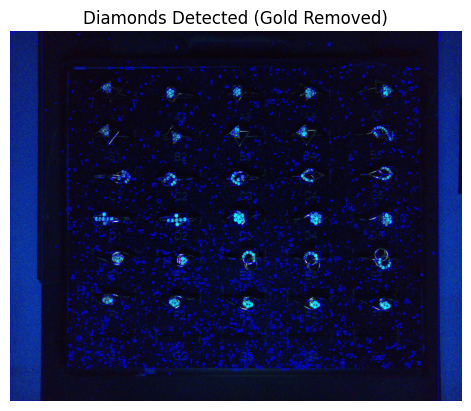

In [6]:
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Diamonds Detected (Gold Removed)')
plt.axis('off')
plt.show()


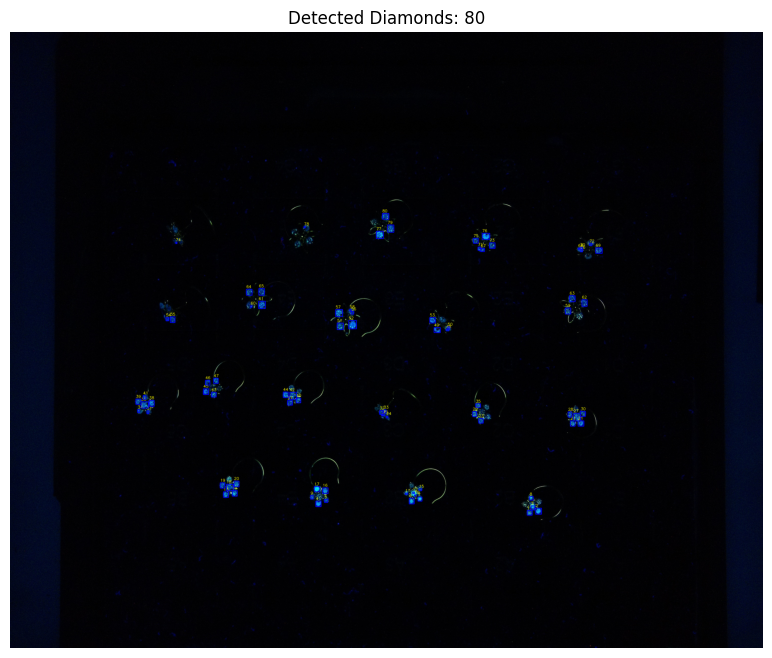

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\febaj\Downloads\Diamond\479_184805_230224-20250717T064456Z-1-001\479_184805_230224\shortphosphorescence.jpg")

#Extract RGB channels
blue = img[:, :, 0]
green = img[:, :, 1]
red = img[:, :, 2]

#Mask regions where blue is dominant
blue_mask = (blue > 100) & (blue > green + 20) & (blue > red + 20)
blue_only = np.zeros_like(blue)
blue_only[blue_mask] = blue[blue_mask]

#Threshold the blue-only image
_, thresh = cv2.threshold(blue_only, 60, 255, cv2.THRESH_BINARY)

#Clean up small noise using morphological operations
kernel = np.ones((3, 3), np.uint8)
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

#Find contours
contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Filter small contours (noise)
min_contour_area = 10  # Change based on size of diamond glow
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

#Annotate image with bounding boxes and labels
output_img = img.copy()
for idx, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Blue box
    cv2.putText(output_img, str(idx + 1), (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)

#result
output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.title(f'Detected Diamonds: {len(filtered_contours)}')
plt.axis('off')
plt.show()


In [ ]:
# Save the high-resolution annotated image
cv2.imwrite('annotateddiamonds.jpg', output_img)

Saved as: annotated_diamonds.jpg


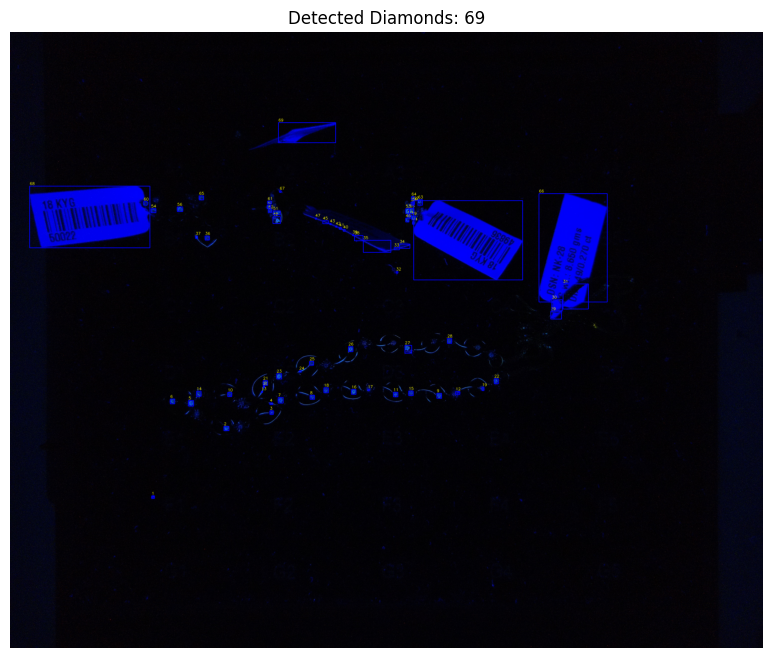

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\febaj\Downloads\Diamond\images\short\shortphosphorescence_5.jpg")

# Extract RGB channels
blue = img[:, :, 0]
green = img[:, :, 1]
red = img[:, :, 2]

#Mask regions where blue is dominant
blue_mask = (blue > 100) & (blue > green + 20) & (blue > red + 20)
blue_only = np.zeros_like(blue)
blue_only[blue_mask] = blue[blue_mask]

#Threshold the blue-only image
_, thresh = cv2.threshold(blue_only, 60, 255, cv2.THRESH_BINARY)

#Clean up small noise using morphological operations
kernel = np.ones((3, 3), np.uint8)
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

#Find contours
contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Filter small contours (noise)
min_contour_area = 10  # Change based on size of diamond glow
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

#Annotate image with bounding boxes and labels
output_img = img.copy()
for idx, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Blue box
    cv2.putText(output_img, str(idx + 1), (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)

output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.title(f'Detected Diamonds: {len(filtered_contours)}')
plt.axis('off')
plt.show()


04/08/2025

In [11]:
import cv2
import numpy as np

def fuse_phosphorescence_with_visible(phosphor_path, visible_path, output_path="fused_diamonds.jpg"):
    # Load images
    img_phosphor = cv2.imread(phosphor_path)
    img_visible = cv2.imread(visible_path)

    # Resize to match (assume same size here; else use cv2.resize)
    if img_phosphor.shape != img_visible.shape:
        img_phosphor = cv2.resize(img_phosphor, (img_visible.shape[1], img_visible.shape[0]))

    # Convert phosphor to grayscale
    gray_phosphor = cv2.cvtColor(img_phosphor, cv2.COLOR_BGR2GRAY)

    # Threshold to create diamond mask
    _, mask = cv2.threshold(gray_phosphor, 20, 255, cv2.THRESH_BINARY)

    # Morphological cleaning
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Optional: Expand the glowing region slightly
    mask = cv2.dilate(mask, kernel, iterations=1)

    # Apply mask to visible image
    fused = cv2.bitwise_and(img_visible, img_visible, mask=mask)

    # Optional: Draw bounding boxes around detected diamonds
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        if w*h > 20:  # ignore small noise
            cv2.rectangle(fused, (x, y), (x+w, y+h), (0, 255, 0), 1)
            cv2.putText(fused, f"{i+1}", (x, y-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    # Save the result
    cv2.imwrite(output_path, fused)
    print(f"[✓] Fused image saved as: {output_path}")

    return fused


In [13]:
fuse_phosphorescence_with_visible(r"C:\Users\febaj\Downloads\Diamond\479_184805_230224-20250717T064456Z-1-001\479_184805_230224\shortphosphorescence.jpg",r"C:\Users\febaj\Downloads\Diamond\479_184805_230224-20250717T064456Z-1-001\479_184805_230224\whitelight.jpg")

[✓] Fused image saved as: fused_diamonds.jpg


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(2456, 3000, 3), dtype=uint8)

In [14]:
import cv2
import numpy as np

def fuse_phosphorescence_with_visible(phosphor_path, visible_path, output_path="fusediamonds.jpg"):
    # Load images
    img_phosphor = cv2.imread(phosphor_path)
    img_visible = cv2.imread(visible_path)

    # Resize to match (assume same size here; else use cv2.resize)
    if img_phosphor.shape != img_visible.shape:
        img_phosphor = cv2.resize(img_phosphor, (img_visible.shape[1], img_visible.shape[0]))

    # Convert phosphor to grayscale
    gray_phosphor = cv2.cvtColor(img_phosphor, cv2.COLOR_BGR2GRAY)

    # Threshold to create diamond mask
    _, mask = cv2.threshold(gray_phosphor, 20, 255, cv2.THRESH_BINARY)

    # Morphological cleaning
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Optional: Expand the glowing region slightly
    mask = cv2.dilate(mask, kernel, iterations=1)

    # Apply mask to visible image
    fused = cv2.bitwise_and(img_visible, img_visible, mask=mask)

    # Optional: Draw bounding boxes around detected diamonds
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        if w*h > 20:  # ignore small noise
            cv2.rectangle(fused, (x, y), (x+w, y+h), (0, 255, 0), 1)
            cv2.putText(fused, f"{i+1}", (x, y-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    # Save the result
    cv2.imwrite(output_path, fused)
    print(f"[✓] Fused image saved as: {output_path}")

    return fused


In [15]:
fuse_phosphorescence_with_visible(r"C:\Users\febaj\Downloads\Diamond\1925_100146_251023-20250717T064804Z-1-001\1925_100146_251023\shortphosphorescence.jpg",r"C:\Users\febaj\Downloads\Diamond\1925_100146_251023-20250717T064804Z-1-001\1925_100146_251023\whitelight.jpg")

[✓] Fused image saved as: fusediamonds.jpg


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(2456, 3000, 3), dtype=uint8)

In [18]:
import cv2
import numpy as np

def detect_filtered_diamonds(image_path, output_path="outputsuperimagefiltered.jpg"):
    # Load
    img = cv2.imread(image_path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect bright glow regions (from diamonds) ---
    _, glow_mask = cv2.threshold(img_gray, 40, 255, cv2.THRESH_BINARY)

    # Morph to clean noise
    kernel = np.ones((3, 3), np.uint8)
    glow_mask = cv2.morphologyEx(glow_mask, cv2.MORPH_OPEN, kernel)
    glow_mask = cv2.dilate(glow_mask, kernel, iterations=1)

    # Remove barcode tags and gold using HSV color ---
    # Bright paper tag removal (white)
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 60, 255])
    tag_mask = cv2.inRange(img_hsv, lower_white, upper_white)

    # Gold glow suppression (yellow range)
    lower_gold = np.array([15, 60, 100])
    upper_gold = np.array([40, 255, 255])
    gold_mask = cv2.inRange(img_hsv, lower_gold, upper_gold)

    # Combine masks to remove from glow mask
    removal_mask = cv2.bitwise_or(tag_mask, gold_mask)
    cleaned_mask = cv2.bitwise_and(glow_mask, cv2.bitwise_not(removal_mask))

    # Contour detection and filtering ---
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output = img.copy()
    count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20 or area > 2500:
            continue  # Remove noise & large tags

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        if aspect_ratio > 3 or aspect_ratio < 0.3:
            continue  # Long rectangles – ignore

        perimeter = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * (area / (perimeter * perimeter)) if perimeter != 0 else 0
        if circularity < 0.35:
            continue

        # Passed all filters – mark it
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 1)
        cv2.putText(output, str(count + 1), (x, y - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
        count += 1

    cv2.imwrite(output_path, output)
    print(f"[✓] Detected diamonds: {count}")
    print(f"[✓] Saved filtered image: {output_path}")

# Run the function
detect_filtered_diamonds(r"C:\Users\febaj\Downloads\Diamond\1925_100146_251023-20250717T064804Z-1-001\1925_100146_251023\shortphosphorescence.jpg")


[✓] Detected diamonds: 77
[✓] Saved filtered image: outputsuperimagefiltered.jpg


06/08/2025

In [19]:
import cv2
import numpy as np

def detect_filtered_diamonds(image_path, output_path="hytr.jpg"):
    # Load
    img = cv2.imread(image_path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect bright glow regions (from diamonds) ---
    _, glow_mask = cv2.threshold(img_gray, 40, 255, cv2.THRESH_BINARY)

    # Morph to clean noise
    kernel = np.ones((3, 3), np.uint8)
    glow_mask = cv2.morphologyEx(glow_mask, cv2.MORPH_OPEN, kernel)
    glow_mask = cv2.dilate(glow_mask, kernel, iterations=1)

    # Remove barcode tags and gold using HSV color ---
    # Bright paper tag removal (white)
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 60, 255])
    tag_mask = cv2.inRange(img_hsv, lower_white, upper_white)

    # Gold glow suppression (yellow range)
    lower_gold = np.array([15, 60, 100])
    upper_gold = np.array([40, 255, 255])
    gold_mask = cv2.inRange(img_hsv, lower_gold, upper_gold)

    # Combine masks to remove from glow mask
    removal_mask = cv2.bitwise_or(tag_mask, gold_mask)
    cleaned_mask = cv2.bitwise_and(glow_mask, cv2.bitwise_not(removal_mask))

    # Contour detection and filtering ---
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output = img.copy()
    count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20 or area > 2500:
            continue  # Remove noise & large tags

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        if aspect_ratio > 3 or aspect_ratio < 0.3:
            continue  # Long rectangles – ignore

        perimeter = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * (area / (perimeter * perimeter)) if perimeter != 0 else 0
        if circularity < 0.35:
            continue

        # Passed all filters – mark it
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 1)
        cv2.putText(output, str(count + 1), (x, y - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
        count += 1

    cv2.imwrite(output_path, output)
    print(f"[✓] Detected diamonds: {count}")
    print(f"[✓] Saved filtered image: {output_path}")

# Run the function
detect_filtered_diamonds(r"C:\Users\febaj\Downloads\Diamond\1925_100146_251023-20250717T064804Z-1-001\1925_100146_251023\superimage.jpg")


[✓] Detected diamonds: 161
[✓] Saved filtered image: hytr.jpg


In [32]:
import cv2
import numpy as np

def detect_filtered_diamonds(image_path, output_path="super4.jpg"):
    # Load
    img = cv2.imread(image_path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect bright glow regions (from diamonds) ---
    _, glow_mask = cv2.threshold(img_gray, 40, 255, cv2.THRESH_BINARY)

    # Morph to clean noise
    kernel = np.ones((3, 3), np.uint8)
    glow_mask = cv2.morphologyEx(glow_mask, cv2.MORPH_OPEN, kernel)
    glow_mask = cv2.dilate(glow_mask, kernel, iterations=1)

    # Remove barcode tags and gold using HSV color ---
    # Bright paper tag removal (white)
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 60, 255])
    tag_mask = cv2.inRange(img_hsv, lower_white, upper_white)

    # Gold glow suppression (yellow range)
    lower_gold = np.array([15, 60, 100])
    upper_gold = np.array([40, 255, 255])
    gold_mask = cv2.inRange(img_hsv, lower_gold, upper_gold)

    # Combine masks to remove from glow mask
    removal_mask = cv2.bitwise_or(tag_mask, gold_mask)
    cleaned_mask = cv2.bitwise_and(glow_mask, cv2.bitwise_not(removal_mask))

    # Contour detection and filtering ---
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output = img.copy()
    count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20 or area > 2500:
            continue  # Remove noise & large tags

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        if aspect_ratio > 3 or aspect_ratio < 0.3:
            continue  # Long rectangles – ignore

        perimeter = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * (area / (perimeter * perimeter)) if perimeter != 0 else 0
        if circularity < 0.35:
            continue

        # Passed all filters – mark it
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 1)
        cv2.putText(output, str(count + 1), (x, y - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
        count += 1

    cv2.imwrite(output_path, output)
    print(f"[✓] Detected diamonds: {count}")
    print(f"[✓] Saved filtered image: {output_path}")

# Run the function
detect_filtered_diamonds(r"C:\Users\febaj\Downloads\Diamond\668_174334_270224-20250717T064609Z-1-001\668_174334_270224\superimage.jpg")


[✓] Detected diamonds: 1704
[✓] Saved filtered image: super4.jpg
